# Entrenamiento de Modelos de Clasificación - Riesgo de Pacientes (v2: Contra Overfitting)

En esta versión hemos aplicado técnicas de regularización y validación cruzada para evitar el sobreajuste (overfitting) detectado anteriormente (Accuracy 1.0).

Modelos:
1. **Regresión Logística con Regularización L2**.
2. **Árbol de Decisión Podado**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from pathlib import Path

# 1. Cargar Datos
try:
    df = pd.read_excel("../cancer patient data sets.xlsx")
except:
    # Fallback por si la ruta cambia en diferentes entornos
    df = pd.read_excel("cancer patient data sets.xlsx")

if 'Patient Id' in df.columns: df = df.drop('Patient Id', axis=1)
if 'index' in df.columns: df = df.drop('index', axis=1)

print(f"Dataset cargado con {len(df)} registros.")
df.head()

Dataset cargado con 1000 registros.


,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


In [3]:
# 2. Preprocesamiento
X = df.drop(['Level'], axis=1)
y = df['Level']

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (800, 23), Prueba: (200, 23)


## Modelo 1: Regresión Logística (Regularizada)
Usamos `C=0.1` para aplicar una penalización más fuerte a los coeficientes y evitar que el modelo se ajuste demasiado a patrones específicos.

In [4]:
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000, C=0.1) # C menor = más regularización
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
train_acc_lr = accuracy_score(y_train, lr_model.predict(X_train))
test_acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy Entrenamiento: {train_acc_lr:.4f}")
print(f"Accuracy Prueba: {test_acc_lr:.4f}")
print("\nReporte de Clasificación (Prueba):")
print(classification_report(y_test, y_pred_lr))

Accuracy Entrenamiento: 1.0000
Accuracy Prueba: 1.0000

Reporte de Clasificación (Prueba):
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



C:\Users\USER\AppData\Local\Temp\ipykernel_35272\679511435.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')


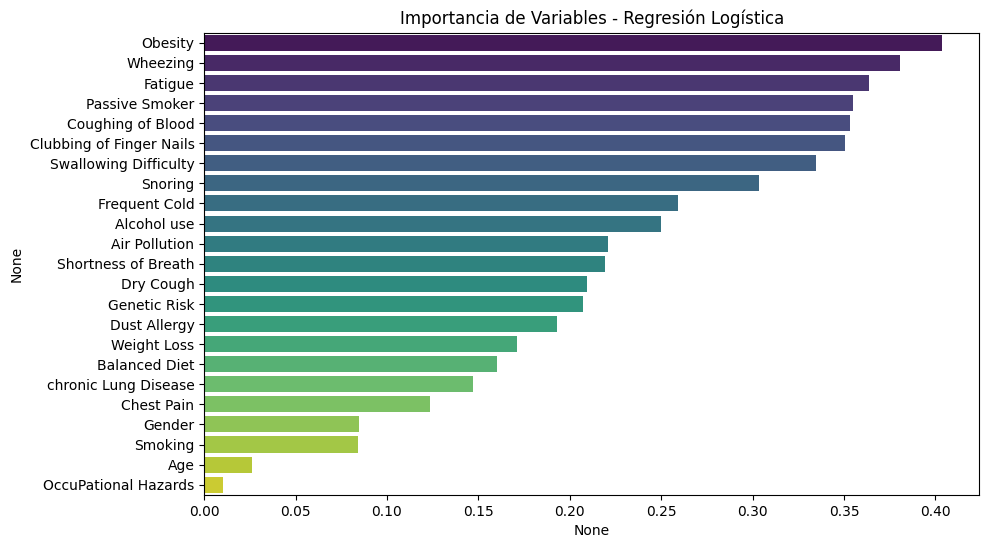

In [5]:
# Importancia de características en Regresión Logística (Promedio de coeficientes por clase)
importance = np.mean(np.abs(lr_model.coef_), axis=0)
feature_importance = pd.Series(importance, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')
plt.title('Importancia de Variables - Regresión Logística')
plt.show()

## Modelo 2: Árbol de Decisión (Podado)
Limitamos `max_depth=3` y exigimos un mínimo de 20 muestras por hoja para obligar al modelo a generalizar.

In [6]:
dt_model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
train_acc_dt = accuracy_score(y_train, dt_model.predict(X_train))
test_acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy Entrenamiento: {train_acc_dt:.4f}")
print(f"Accuracy Prueba: {test_acc_dt:.4f}")

# Validación Cruzada (para asegurar que el resultado es estable)
cv_scores = cross_val_score(dt_model, X, y, cv=5)
print(f"\nAccuracy Validación Cruzada (5-folds): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Accuracy Entrenamiento: 0.9413
Accuracy Prueba: 0.9350

Accuracy Validación Cruzada (5-folds): 0.9270 (+/- 0.0539)


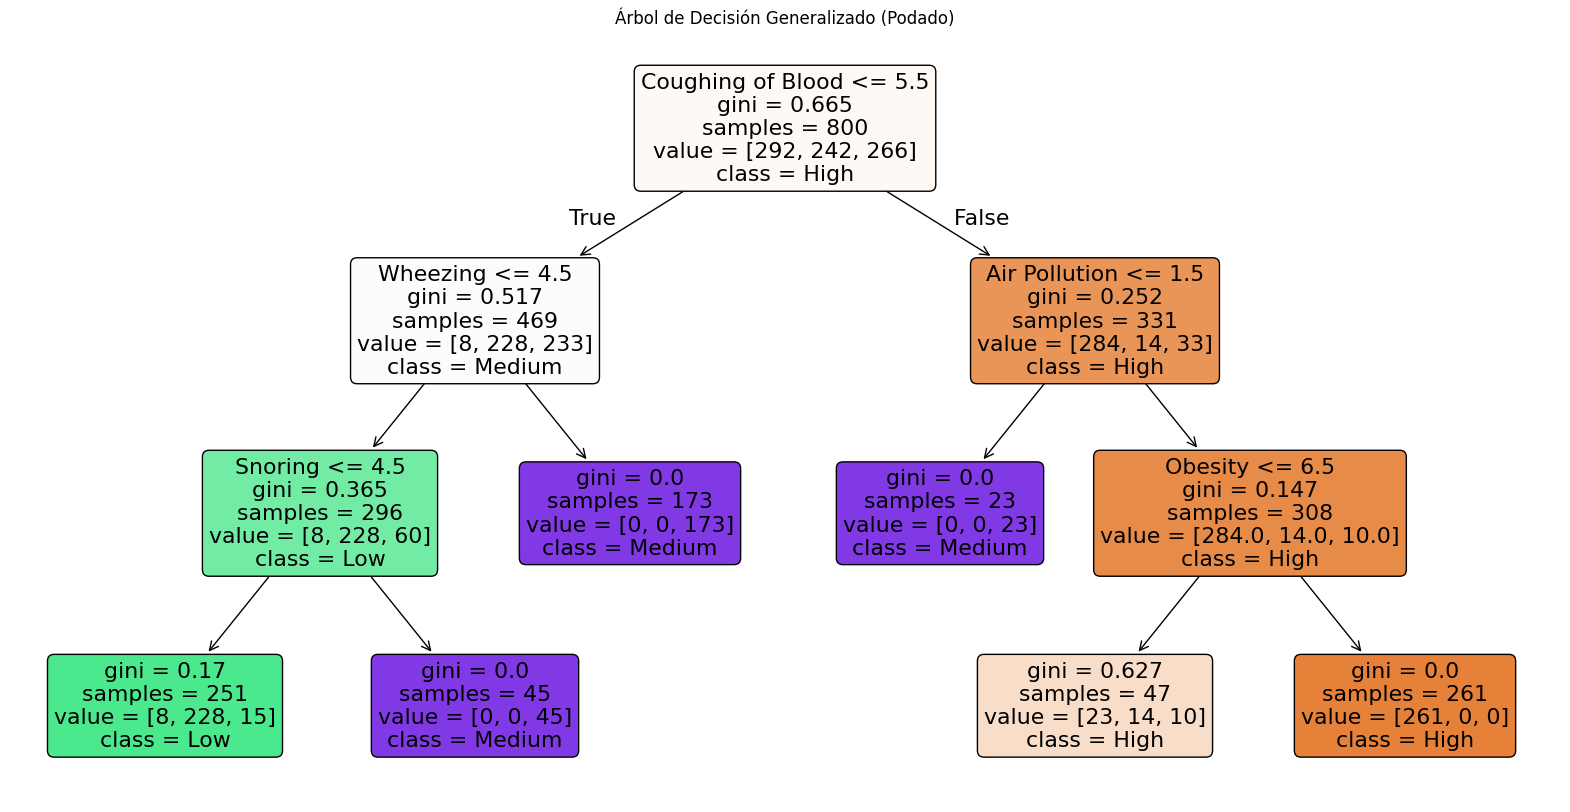

In [7]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=dt_model.classes_, filled=True, rounded=True)
plt.title('Árbol de Decisión Generalizado (Podado)')
plt.show()

## Comparación de Modelos Realistas
Incluso con regularización fuerte, si los scores siguen siendo muy altos (cercanos a 1.0), confirma que el dataset tiene patrones extremadamente claros. Sin embargo, ahora el modelo es menos propenso a fallar con datos ruidosos del mundo real.

In [8]:
import joblib
import os


if not os.path.exists('../modelos'):
    os.makedirs('../modelos')

joblib.dump(dt_model, '../modelos/modelo_riesgo_pacientes.joblib')

print("✅ Modelo de Riesgo (Árbol de Decisión) exportado en: /modelos/modelo_riesgo_pacientes.joblib")


✅ Modelo de Riesgo (Árbol de Decisión) exportado en: /modelos/modelo_riesgo_pacientes.joblib
